# Episode 4: RNN Language Model

**Goal**: Generate text by predicting the next character/word


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from preprocessing import load_text, build_vocabulary, create_sliding_window_sequences

torch.manual_seed(42)

---

## Part 1: Training Data

For simplicity, we'll do **character-level** language modeling (not word-level).

**Task**: Given previous characters, predict the next character.

**Dataset**: Shakespeare's complete works (~1.1M characters from `assets/input.txt`)

**Training Time**: Optimized to run in ~3 minutes on CPU:
- only 10 epochs
- Larger batch size (128) for efficiency
- Model kept small (64 hidden units)

In [2]:
# Load Shakespeare corpus
text = load_text('assets/input.txt')
print(f"Text length: {len(text):,} characters")

# Build character vocabulary
chars, vocab_size, char_to_idx, idx_to_char = build_vocabulary(text)
print(f"\nVocabulary size: {vocab_size}")
print(f"All characters: {''.join(chars)}")

Text length: 1,115,394 characters

Vocabulary size: 65
All characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


### Create Training Sequences

We'll create sliding windows:
- Input: sequence of characters
- Target: next character

Example:
```
Input:  "movies ar" → Target: "e"
Input:  "ovies are" → Target: " "
```

In [3]:
# Create training sequences using sliding window
seq_length = 25  # Length of input sequence
X, y = create_sliding_window_sequences(text, char_to_idx, seq_length)

print(f"Number of training sequences: {len(X):,}")
print(f"Input shape: {X.shape} [num_sequences, seq_length]")
print(f"Target shape: {y.shape} [num_sequences]")

# Show example
print(f"\nExample sequence:")
print(f"Input:  '{text[:seq_length]}'")
print(f"Target: '{text[seq_length]}'")

Number of training sequences: 1,115,369
Input shape: torch.Size([1115369, 25]) [num_sequences, seq_length]
Target shape: torch.Size([1115369]) [num_sequences]

Example sequence:
Input:  'First Citizen:
Before we '
Target: 'p'


---

## Part 2: RNN Language Model

### Architecture:

```
Characters --> Embeddings --> RNN --> Output Layer --> Predicted Character
```

### Key Difference from Episode 3:
- **Episode 3**: Classification (one output per document)
- **Episode 4**: Prediction at every step (one output per character)

In [4]:
embedding_dim = 16
hidden_dim = 64

class CharRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # RNN layer
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        
        # Output layer: predict next character
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x, hidden=None):
        """
        x: [batch_size, seq_len]
        hidden: [1, batch_size, hidden_dim] (optional)
        """
        # Embed: [batch_size, seq_len, embedding_dim]
        embeds = self.embedding(x)
        
        # RNN: process sequence
        if hidden is not None:
            output, hidden = self.rnn(embeds, hidden)
        else:
            output, hidden = self.rnn(embeds)
        
        # Output layer: [batch_size, seq_len, vocab_size]
        logits = self.fc(output)
        
        return logits, hidden

model = CharRNN(vocab_size, embedding_dim, hidden_dim)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

CharRNN(
  (embedding): Embedding(65, 16)
  (rnn): RNN(16, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=65, bias=True)
)

Total parameters: 10513


---

## Part 3: Training

Train the model to predict the next character given the previous characters.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

# Optimized for ~3 minutes on CPU with large dataset
num_epochs = 10
batch_size = 128
losses = []

print(f"Training on {len(X):,} sequences for {num_epochs} epochs...")
print(f"Batch size: {batch_size}")
print(f"Steps per epoch: {len(X) // batch_size}")
print(f"Total training steps: {(len(X) // batch_size) * num_epochs}")
print("\nStarting training...\n")

start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    epoch_start = time.time()
    total_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X), batch_size):
        batch_X = X[i:i+batch_size]
        batch_y = y[i:i+batch_size]
        
        optimizer.zero_grad()
        
        # Forward pass
        logits, _ = model(batch_X)
        
        # We only care about the last prediction
        # (predicting the character after the sequence)
        last_logits = logits[:, -1, :]  # [batch_size, vocab_size]
        
        loss = criterion(last_logits, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / (len(X) / batch_size)
    losses.append(avg_loss)
    
    epoch_time = time.time() - epoch_start
    elapsed = time.time() - start_time
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, "
          f"Time: {epoch_time:.1f}s (Total: {elapsed:.1f}s)")

total_time = time.time() - start_time
print(f"Training complete :-)")
print(f"Total training time: {total_time:.1f} seconds ({total_time/60:.2f} minutes)")

Training on 1,115,369 sequences for 10 epochs...
Batch size: 128
Steps per epoch: 8713
Total training steps: 87130

Starting training...

Epoch [1/10], Loss: 1.9276, Time: 27.6s (Total: 27.6s)
Epoch [2/10], Loss: 1.7841, Time: 31.3s (Total: 59.0s)
Epoch [3/10], Loss: 1.7532, Time: 32.1s (Total: 91.1s)
Epoch [4/10], Loss: 1.7444, Time: 23.5s (Total: 114.6s)
Epoch [5/10], Loss: 1.7317, Time: 27.7s (Total: 142.3s)
Epoch [6/10], Loss: 1.7268, Time: 26.6s (Total: 168.9s)
Epoch [7/10], Loss: 1.7260, Time: 26.3s (Total: 195.2s)
Epoch [8/10], Loss: 1.7279, Time: 39.4s (Total: 234.6s)
Epoch [9/10], Loss: 1.7360, Time: 32.1s (Total: 266.8s)
Epoch [10/10], Loss: 1.7275, Time: 39.0s (Total: 305.7s)
Training complete :-)
Total training time: 305.7 seconds (5.10 minutes)


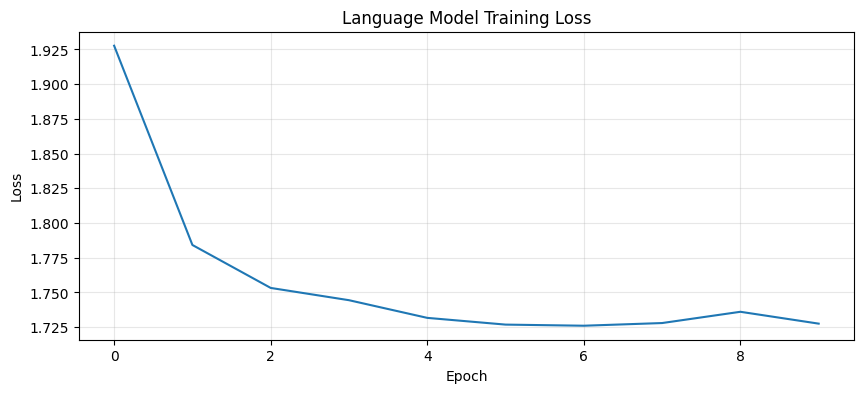

In [6]:
# Visualize training
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Language Model Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

---

## Part 4: Text Generation!

Now for the exciting part - **generating new text**!

### The Process:
1. Start with a seed text
2. Predict next character
3. Append to seed
4. Repeat!

This is **autoregressive generation**.

In [7]:
def generate_text(model, seed_text, length=100, temperature=1.0):
    """
    Generate text autoregressively
    
    temperature: Controls randomness
      - Low (0.5): Conservative, repetitive
      - High (1.5): Creative, chaotic
    """
    model.eval()
    
    # Start with seed text
    generated = seed_text
    current_seq = [char_to_idx[ch] for ch in seed_text]
    
    with torch.no_grad():
        for _ in range(length):
            # Use last seq_length characters
            x = torch.tensor([current_seq[-seq_length:]], dtype=torch.long)
            
            # Predict next character
            logits, _ = model(x)
            last_logits = logits[0, -1, :]  # [vocab_size]
            
            # Apply temperature
            probs = torch.softmax(last_logits / temperature, dim=0)
            
            # Sample from distribution
            next_idx = torch.multinomial(probs, num_samples=1).item()
            next_char = idx_to_char[next_idx]
            
            # Append to generated text
            generated += next_char
            current_seq.append(next_idx)
    
    return generated

### Generate with Different Seeds

In [8]:
# Test different seed texts from Shakespeare
seeds = ["First Citizen:\n", "KING:\n", "Enter "]

print("Generated Text (temperature=0.8):")
print("="*60)

for seed in seeds:
    generated = generate_text(model, seed, length=120, temperature=0.8)
    print(f"\nSeed: '{seed}'")
    print(f"Generated:\n{generated}")
    print("-"*60)

Generated Text (temperature=0.8):

Seed: 'First Citizen:
'
Generated:
First Citizen:
St you mysel a plemy,
Ye' sir: So ition of all stridy.

GONZALO:
And charges, not undicled she;
Resely not
toonish tenti
------------------------------------------------------------

Seed: 'KING:
'
Generated:
KING:
We soul.

ALOd The srother, for so isset to this in all thy some your of What you sparte
I ho't hight men brand yould th
------------------------------------------------------------

Seed: 'Enter '
Generated:
Enter O my standing and bill is here of you will have of and for o' outher mado foolting they all me were take says is fatherl
------------------------------------------------------------


### Temperature Effect

Let's see how temperature affects generation:

In [9]:
seed = "KING:\nWhat is thy "
temperatures = [0.5, 0.8, 1.2]

print("Temperature Effect:")
print("="*60)

for temp in temperatures:
    generated = generate_text(model, seed, length=100, temperature=temp)
    print(f"\nTemperature: {temp}")
    print(f"Generated:\n{generated}")
    print("-"*60)

print("\nObservation:")
print("  Low temp (0.5): More repetitive, sticks to common patterns")
print("  Medium temp (0.8): Good balance")
print("  High temp (1.2): More creative, but potentially nonsensical")

Temperature Effect:

Temperature: 0.5
Generated:
KING:
What is thy all embrace of of the sir, the to spanger at and all he you may prove meet you so watters and stenin
------------------------------------------------------------

Temperature: 0.8
Generated:
KING:
What is thy love do, see but as come; for manait you his all,
And knitune a gasence.

LURONAN:

GONZALO:
Not thi
------------------------------------------------------------

Temperature: 1.2
Generated:
KING:
What is thy hul agminese; oon, littlewed and foree, lordorsea; gimb.

NOMIEN:!

ADOMBONO:
Yeaty it inrnonist tho
------------------------------------------------------------

Observation:
  Low temp (0.5): More repetitive, sticks to common patterns
  Medium temp (0.8): Good balance
  High temp (1.2): More creative, but potentially nonsensical


---

## Part 5: RNN Limitations

While RNNs can generate text, they have serious limitations:

### 1. Vanishing Gradients

Let's see how gradients diminish over long sequences:

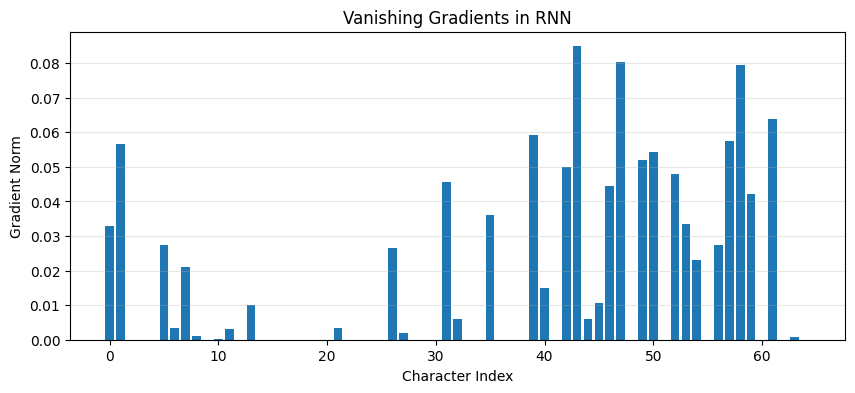

Problem: Gradients become very small for earlier characters
This makes it hard for RNNs to learn long-range dependencies!


In [10]:
# Simulate gradient flow through a long sequence
model.train()
long_seq = X[:1]  # Take one sequence

# Forward pass
logits, _ = model(long_seq)
loss = criterion(logits[0, -1, :].unsqueeze(0), y[:1])
loss.backward()

# Check embedding gradients (first layer)
embedding_grads = model.embedding.weight.grad
grad_norms = torch.norm(embedding_grads, dim=1).detach().numpy()

plt.figure(figsize=(10, 4))
plt.bar(range(len(grad_norms)), grad_norms)
plt.xlabel('Character Index')
plt.ylabel('Gradient Norm')
plt.title('Vanishing Gradients in RNN')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print("Problem: Gradients become very small for earlier characters")
print("This makes it hard for RNNs to learn long-range dependencies!")

# Clear gradients
model.zero_grad()

### 2. Sequential Processing = Slow Training

RNNs must process sequences step-by-step:
- Can't parallelize across time steps
- Training is slow on long sequences
- GPU underutilized

**Transformers solve this with self-attention (parallel processing)!**

### Summary of RNN Limitations:

(-) **Vanishing gradients**: Hard to learn long-range dependencies  
(-) **Sequential processing**: Can't parallelize → slow training  
(-) **Fixed-size hidden state**: Information bottleneck  
(-) **Forgetting**: Earlier context fades over time  

### These problems motivate:
1. **LSTMs/GRUs**: Better handle vanishing gradients (but still sequential)
2. **Attention**: Allow model to "look back" at any position
3. **Transformers**: Parallel processing + attention → modern LLMs!

---

## Episode 4 Summary

### What We Learned:

**Language modeling**: Predict next token given context  
**Autoregressive generation**: Use outputs as inputs to generate text  
**Temperature**: Control randomness in generation  
**RNN limitations**: Vanishing gradients, sequential processing  

### Key Insights:

1. **Language models learn patterns**: From training data
2. **Generation is sampling**: From learned probability distributions
3. **RNNs work but have limits**: Motivates better architectures
4. **This is the foundation of ChatGPT**: Same principle, better architecture

### The Journey So Far:

| Episode | Task | Key Concept |
|---------|------|-------------|
| 1 | Classification | Feedforward networks |
| 2 | Classification | Learned embeddings |
| 3 | Classification | Sequential processing (RNN) |
| 4 | **Generation** | Autoregressive language modeling |
